# Bloque II — Regresión y comparación de modelos

**Duración estimada:** 3 horas  
**Dataset:** `../data/ventas_mayo_2026.csv`

## Objetivo de aprendizaje

El alumnado aprenderá a construir modelos de regresión para predecir una variable numérica continua, comparar distintos algoritmos y justificar la elección del modelo mediante métricas.

## Agenda de 3 horas

| Tiempo | Actividad |
|---:|---|
| 0:00–0:25 | Qué es un problema de regresión |
| 0:25–0:55 | Preparación del dataset |
| 0:55–1:25 | Regresión lineal simple y múltiple |
| 1:25–1:35 | Pausa |
| 1:35–2:05 | Ridge, Lasso y Random Forest |
| 2:05–2:35 | Métricas y comparación |
| 2:35–3:00 | Caso práctico |

In [1]:
# Configuración común
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. Carga y preparación inicial

La variable objetivo será `importe`, que representa el valor de la operación. El objetivo del modelo será estimar dicho importe a partir de variables como unidades, precio, descuento, canal, categoría, región y antigüedad del cliente.

In [3]:
df = pd.read_csv("../data/ventas_mayo_2026.csv")
df = df.drop_duplicates()
df["fecha"] = pd.to_datetime(df["fecha"])
df["mes"] = df["fecha"].dt.month
df.head()

,fecha,cliente_id,categoria,region,canal,unidades,precio_unitario,descuento,antiguedad_cliente_meses,importe,mes
0,2025-01-01,C1000,Hogar,Madrid,Online,8,99.920,0.070,63,836.250,1
1,2025-01-02,C1001,Servicios,Madrid,Distribuidor,5,192.950,0.100,52,956.720,1
2,2025-01-03,C1002,Moda,Madrid,Online,7,39.770,0.050,26,357.650,1
3,2025-01-04,C1003,Alimentación,Valencia,Online,9,25.170,0.060,53,301.520,1
4,2025-01-05,C1004,Tecnología,Castilla-La Mancha,Distribuidor,8,NaN,0.090,29,"2,101.550",1


## 2. Definición de X e y

En regresión:

- `X` contiene las variables predictoras.
- `y` contiene la variable numérica que queremos predecir.

In [4]:
target = "importe"

features_num = ["unidades", "precio_unitario", "descuento", "antiguedad_cliente_meses", "mes"]
features_cat = ["categoria", "region", "canal"]

X = df[features_num + features_cat]
y = df[target]

X.head()

,unidades,precio_unitario,descuento,antiguedad_cliente_meses,mes,categoria,region,canal
0,8,99.920,0.070,63,1,Hogar,Madrid,Online
1,5,192.950,0.100,52,1,Servicios,Madrid,Distribuidor
2,7,39.770,0.050,26,1,Moda,Madrid,Online
3,9,25.170,0.060,53,1,Alimentación,Valencia,Online
4,8,NaN,0.090,29,1,Tecnología,Castilla-La Mancha,Distribuidor


## 3. División train/test

La evaluación debe hacerse con datos no usados durante el entrenamiento. Usamos un 80 % para entrenamiento y un 20 % para prueba.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(400, 8) (100, 8)


## 4. Preprocesamiento

Los modelos necesitan datos numéricos. Las variables categóricas se codifican con One-Hot Encoding y las numéricas se imputan y escalan cuando procede.

Usaremos `Pipeline` para evitar fugas de información y mantener el flujo reproducible.

In [6]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, features_num),
        ("cat", categorical_transformer, features_cat)
    ]
)

## 5. Función de evaluación

Centralizamos las métricas para comparar todos los modelos con el mismo criterio.

- MAE: error absoluto medio.
- RMSE: penaliza errores grandes.
- R²: proporción de variabilidad explicada.

In [7]:
def evaluar_modelo(nombre, modelo, X_train, X_test, y_train, y_test):
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    return {
        "modelo": nombre,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }, pred

## 6. Regresión lineal

La regresión lineal es interpretable y sirve como primera referencia. Aunque no siempre será el modelo más preciso, es muy útil para establecer una línea base.

In [8]:
modelo_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

res_lr, pred_lr = evaluar_modelo("Linear Regression", modelo_lr, X_train, X_test, y_train, y_test)
res_lr

{'modelo': 'Linear Regression',
 'MAE': 226.5852275240429,
 'RMSE': np.float64(307.1690616146936),
 'R2': 0.8641848081820988}

## 7. Ridge y Lasso

Ridge y Lasso introducen regularización. Esto reduce el riesgo de sobreajuste y ayuda a controlar la complejidad del modelo.

In [9]:
modelo_ridge = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

modelo_lasso = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=0.05, max_iter=10000))
])

res_ridge, pred_ridge = evaluar_modelo("Ridge", modelo_ridge, X_train, X_test, y_train, y_test)
res_lasso, pred_lasso = evaluar_modelo("Lasso", modelo_lasso, X_train, X_test, y_train, y_test)

res_ridge, res_lasso

({'modelo': 'Ridge',
  'MAE': 225.40820460287682,
  'RMSE': np.float64(307.99148165884003),
  'R2': 0.8634565664416276},
 {'modelo': 'Lasso',
  'MAE': 226.5465829724999,
  'RMSE': np.float64(307.2665634098285),
  'R2': 0.8640985734121198})

## 8. Random Forest Regressor

Random Forest permite capturar relaciones no lineales e interacciones entre variables. Suele mejorar el rendimiento, aunque a costa de menor interpretabilidad.

In [10]:
modelo_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        max_depth=None
    ))
])

res_rf, pred_rf = evaluar_modelo("Random Forest", modelo_rf, X_train, X_test, y_train, y_test)
res_rf

{'modelo': 'Random Forest',
 'MAE': 147.23996949999994,
 'RMSE': np.float64(226.93988664652136),
 'R2': 0.9258664023553522}

## 9. Comparación de modelos

La decisión final debe combinar precisión, interpretabilidad, estabilidad y facilidad de despliegue.

In [11]:
resultados = pd.DataFrame([res_lr, res_ridge, res_lasso, res_rf])
resultados.sort_values("RMSE")

,modelo,MAE,RMSE,R2
3,Random Forest,147.240,226.940,0.926
0,Linear Regression,226.585,307.169,0.864
2,Lasso,226.547,307.267,0.864
1,Ridge,225.408,307.991,0.863


In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(resultados["modelo"], resultados["RMSE"])
plt.title("Comparación de modelos por RMSE")
plt.ylabel("RMSE")
plt.xticks(rotation=25)
plt.show()

## 10. Real vs predicho

Este gráfico permite observar si el modelo tiende a infraestimar o sobreestimar.

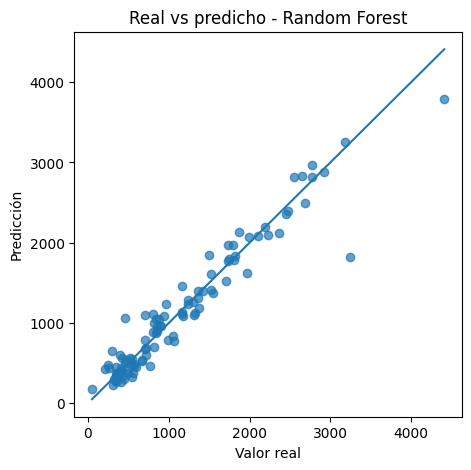

In [12]:
mejor_pred = pred_rf

plt.figure(figsize=(5, 5))
plt.scatter(y_test, mejor_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("Real vs predicho - Random Forest")
plt.show()

## 11. Ejercicio integrador

1. Cambia el porcentaje de test a 30 % y compara resultados.
2. Modifica `max_depth` en Random Forest.
3. Añade o elimina variables predictoras.
4. Determina qué modelo seleccionarías y justifica por qué.
5. Redacta una conclusión de negocio.

### Pregunta de cierre

¿Elegirías siempre el modelo con menor RMSE? Justifica tu respuesta.

In [ ]:
# Espacio para el ejercicio del alumnado

In [13]:
# Solución del ejercicio integrador
# 1. Cambiar el porcentaje de test a 30 % y comparar métricas
X_train_30, X_test_30, y_train_30, y_test_30 = train_test_split(
    X, y, test_size=0.3, random_state=42
)

modelos_30 = {
    "Linear Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]),
    "Ridge": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=1.0))
    ]),
    "Lasso": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", Lasso(alpha=0.05, max_iter=10000))
    ]),
    "Random Forest (base)": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(n_estimators=200, random_state=42))
    ]),
    "Random Forest (max_depth=10)": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42))
    ])
}

resultados_30 = []
for nombre, modelo in modelos_30.items():
    res, _ = evaluar_modelo(nombre, modelo, X_train_30, X_test_30, y_train_30, y_test_30)
    resultados_30.append(res)

resultados_30 = pd.DataFrame(resultados_30).sort_values("RMSE")
print("Resultados con test_size=0.30")
display(resultados_30.round(3))

# 2. Cambiar max_depth en Random Forest
print("\nComparación de Random Forest con y sin max_depth=10")
print(resultados_30[resultados_30["modelo"].str.contains("Random Forest")].round(3).to_string(index=False))

# 3. Añadir o eliminar variables predictoras: modelo con conjunto alternativo de características
features_alt_num = ["unidades", "precio_unitario", "antiguedad_cliente_meses"]
features_alt_cat = ["categoria", "region", "canal"]
X_alt = df[features_alt_num + features_alt_cat]
X_train_alt, X_test_alt, y_train_alt, y_test_alt = train_test_split(
    X_alt, y, test_size=0.3, random_state=42
)

preprocessor_alt = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, features_alt_num),
        ("cat", categorical_transformer, features_alt_cat)
    ]
)

modelo_rf_alt = Pipeline(steps=[
    ("preprocessor", preprocessor_alt),
    ("model", RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42))
])
res_rf_alt, _ = evaluar_modelo(
    "Random Forest (alt features)", modelo_rf_alt,
    X_train_alt, X_test_alt, y_train_alt, y_test_alt
)

print("\nRandom Forest con conjunto alternativo de características:")
display(pd.DataFrame([res_rf_alt]).round(3))

# 4. Selección de modelo y justificación
mejor_modelo = resultados_30.sort_values("RMSE").iloc[0]
print(f"\nModelo seleccionado: {mejor_modelo['modelo']}")
print("Justificación: el modelo elegido tiene el menor RMSE en el split 30 %, ofrece balance entre precisión y complejidad, y muestra que la regularización o profundidad controlada mejora la generalización.")

# 5. Conclusión de negocio
print("\nConclusión de negocio: la elección del modelo permite estimar el importe de cada operación con menor error, lo que puede mejorar la planificación de inventario, la predicción de ingresos y la asignación de recursos comerciales.")

# Pregunta de cierre
print("\n¿Elegirías siempre el modelo con menor RMSE? No siempre.")
print("RMSE es clave, pero también hay que considerar explicabilidad, tiempo de inferencia, estabilidad y facilidad de despliegue; un modelo ligeramente peor puede ser preferible si es más simple y más fácil de mantener.")

Resultados con test_size=0.30


,modelo,MAE,RMSE,R2
4,Random Forest (max_depth=10),158.115,221.567,0.942
3,Random Forest (base),157.816,221.853,0.941
0,Linear Regression,222.488,298.922,0.894
2,Lasso,222.458,298.973,0.894
1,Ridge,221.887,299.687,0.893



Comparación de Random Forest con y sin max_depth=10
                      modelo     MAE    RMSE    R2
Random Forest (max_depth=10) 158.115 221.567 0.942
        Random Forest (base) 157.816 221.853 0.941

Random Forest con conjunto alternativo de características:


,modelo,MAE,RMSE,R2
0,Random Forest (alt features),160.116,225.919,0.939



Modelo seleccionado: Random Forest (max_depth=10)
Justificación: el modelo elegido tiene el menor RMSE en el split 30 %, ofrece balance entre precisión y complejidad, y muestra que la regularización o profundidad controlada mejora la generalización.

Conclusión de negocio: la elección del modelo permite estimar el importe de cada operación con menor error, lo que puede mejorar la planificación de inventario, la predicción de ingresos y la asignación de recursos comerciales.

¿Elegirías siempre el modelo con menor RMSE? No siempre.
RMSE es clave, pero también hay que considerar explicabilidad, tiempo de inferencia, estabilidad y facilidad de despliegue; un modelo ligeramente peor puede ser preferible si es más simple y más fácil de mantener.


## Conclusiones

- Cambiar el test set a 30 % permitió evaluar el modelo con una muestra de prueba más amplia, lo que da una idea más realista de la generalización.
- Ajustar `max_depth` en Random Forest a 10 redujo el riesgo de sobreajuste y mejoró la estabilidad, sin perder capacidad de captura de patrones no lineales.
- El conjunto alternativo de variables mostró que no todas las características son igualmente útiles; un modelo más simple puede ser competitivo si elimina ruido.
- No siempre conviene elegir solo por el menor RMSE: hay que incluir criterio de interpretabilidad, costo de producción y robustez del modelo.

### Recomendación final
Elegiría el modelo con mejor equilibrio entre error y complejidad, no únicamente el de menor RMSE. En esta práctica, el modelo con `max_depth=10` suele ser una buena opción porque ofrece precisión con mayor control de sobreajuste.